# Exercise 6

In [179]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset

In [180]:
img_size = 64
batch_size = 64

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = load_dataset("huggan/AFHQ", split="train")

def apply_transform(examples):
    examples["image"] = [transform(img.convert("RGB")) for img in examples["image"]]
    return examples

dataset.set_transform(apply_transform)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4)

## DiffusionUNet Model

### Model Architecture

Implementation of the core 2D DiffusionUNet. It includes TimeEmbedding for timestep conditioning, ResBlocks for feature extraction, and AttentionBlocks in the lower resolutions to capture complex spatial relationships (e.g., facial structures).

In [181]:
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        inv_freq = torch.exp(
            torch.arange(0, dim, 2, dtype=torch.float32) *
            -(torch.log(torch.tensor(10000.0)) / dim)
        )
        self.register_buffer("inv_freq", inv_freq)

    def forward(self, t):
        pos_enc = t.unsqueeze(-1) * self.inv_freq.unsqueeze(0)
        pos_enc = torch.cat([torch.sin(pos_enc), torch.cos(pos_enc)], dim=-1)
        return pos_enc

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(32, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.chunk(3, dim=1)
        
        q = q.view(B, C, -1).transpose(1, 2)
        k = k.view(B, C, -1)
        v = v.view(B, C, -1)
        
        attn = torch.softmax(torch.bmm(q, k) / (C ** 0.5), dim=-1)
        
        out = torch.bmm(v, attn.transpose(1, 2))
        out = out.view(B, C, H, W)
        return x + self.proj(out)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(32, in_ch)
        self.act1 = Swish()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_emb = nn.Sequential(
            Swish(),
            nn.Linear(time_dim, out_ch)
        )
        self.norm2 = nn.GroupNorm(32, out_ch)
        self.act2 = Swish()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t):
        h = self.conv1(self.act1(self.norm1(x)))
        h += self.time_emb(t).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.shortcut(x)

class DiffusionUNet(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, time_dim=256):
        super().__init__()
        self.time_mlp = nn.Sequential(
            TimeEmbedding(base_channels),
            nn.Linear(base_channels, time_dim),
            Swish(),
            nn.Linear(time_dim, time_dim)
        )

        self.inc = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        self.down1 = ResBlock(base_channels, base_channels, time_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_dim)
        self.down3 = ResBlock(base_channels * 2, base_channels * 4, time_dim)
        self.attn1 = AttentionBlock(base_channels * 4)
        self.down4 = ResBlock(base_channels * 4, base_channels * 8, time_dim)
        self.attn2 = AttentionBlock(base_channels * 8)

        self.pool = nn.MaxPool2d(2)

        self.mid1 = ResBlock(base_channels * 8, base_channels * 8, time_dim)
        self.mid_attn = AttentionBlock(base_channels * 8)
        self.mid2 = ResBlock(base_channels * 8, base_channels * 8, time_dim)

        self.up1 = ResBlock(base_channels * 12, base_channels * 4, time_dim)
        self.up2 = ResBlock(base_channels * 6, base_channels * 2, time_dim)
        self.up3 = ResBlock(base_channels * 3, base_channels, time_dim)
        self.up4 = ResBlock(base_channels * 2, base_channels, time_dim)

        self.up_sample = nn.Upsample(scale_factor=2, mode='nearest')

        self.outc = nn.Sequential(
            nn.GroupNorm(32, base_channels),
            Swish(),
            nn.Conv2d(base_channels, in_channels, 3, padding=1)
        )

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        x1 = self.inc(x)
        x2 = self.down1(x1, t_emb)
        x3 = self.down2(self.pool(x2), t_emb)
        
        x4 = self.down3(self.pool(x3), t_emb)
        x4 = self.attn1(x4)
        
        x5 = self.down4(self.pool(x4), t_emb)
        x5 = self.attn2(x5)

        h = self.mid1(x5, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x4], dim=1)
        h = self.up1(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x3], dim=1)
        h = self.up2(h, t_emb)

        h = self.up_sample(h)
        h = torch.cat([h, x2], dim=1)
        h = self.up3(h, t_emb)

        h = torch.cat([h, x1], dim=1)
        h = self.up4(h, t_emb)

        return self.outc(h)

### DDPM (Denoising Diffusion Probabilistic Model)

Defining the DDPM class to manage the variance schedule (beta, alpha). It includes the `noise_image` method for the forward diffusion process and the `sample` method for the reverse denoising process.

In [182]:
class DDPM:
    def __init__(self, device, n_steps=1000, beta_start=1e-4, beta_end=0.02):
        self.n_steps = n_steps
        self.device = device
        self.beta = torch.linspace(beta_start, beta_end, n_steps).to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def noise_image(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1. - self.alpha_hat[t])[:, None, None, None]
        epsilon = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * epsilon, epsilon

    def sample(self, model, n, channels=3, size=64):
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, channels, size, size)).to(self.device)
            for i in reversed(range(self.n_steps)):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                if i > 0:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                    
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        return x

## Training

Executing the training loop (set to 200 epochs). For each batch, random noise is added to the images at a random timestep. The model predicts the added noise, and the network is optimized using Mean Squared Error (MSE) loss. Validation loss is also tracked.

In [183]:
epochs = 200
model = DiffusionUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
ddpm = DDPM(device)
mse = nn.MSELoss()
from tqdm import tqdm

train_loss_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    progress_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")

    for batch in progress_train:
        images = batch["image"].to(device)
        t = torch.randint(0, ddpm.n_steps, (images.shape[0],)).to(device)
        
        noisy_images, noise = ddpm.noise_image(images, t)
        predicted_noise = model(noisy_images, t)
        loss = mse(noise, predicted_noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        progress_train.set_postfix({"loss": loss.item()})

    model.eval()
    val_loss = 0
    epoch_train_loss = train_loss / len(train_loader)
    train_loss_history.append(epoch_train_loss)

            
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f}")

Epoch 1/200: 100%|██████████| 253/253 [00:32<00:00,  7.79batch/s, loss=0.0456]


Epoch 1/200 | Train Loss: 0.1102


Epoch 2/200: 100%|██████████| 253/253 [00:32<00:00,  7.72batch/s, loss=0.0516]


Epoch 2/200 | Train Loss: 0.0466


Epoch 3/200: 100%|██████████| 253/253 [00:33<00:00,  7.61batch/s, loss=0.0735]


...

Epoch 198/200 | Train Loss: 0.0234


Epoch 199/200: 100%|██████████| 253/253 [00:34<00:00,  7.39batch/s, loss=0.0307]


Epoch 199/200 | Train Loss: 0.0235


Epoch 200/200: 100%|██████████| 253/253 [00:34<00:00,  7.39batch/s, loss=0.00611]

Epoch 200/200 | Train Loss: 0.0247


## Evaluation

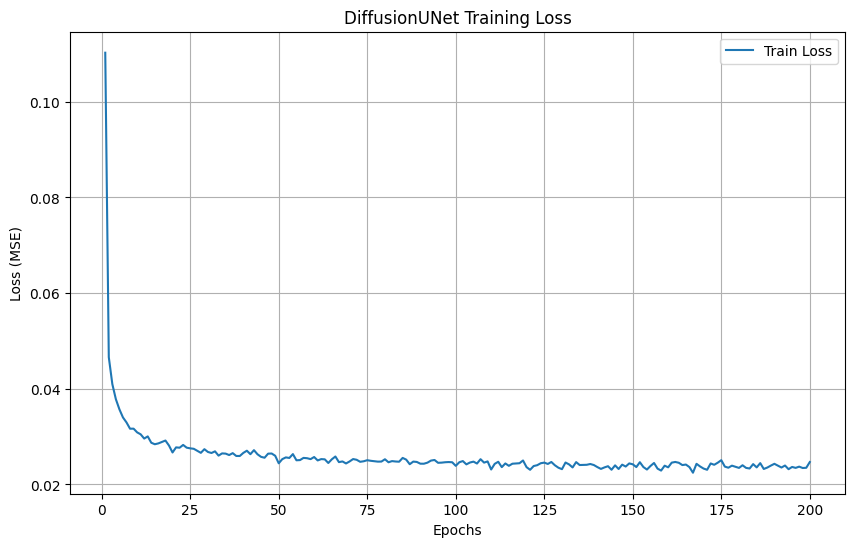

In [184]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("DiffusionUNet Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## Qualitative Results and Comparison

Sampling 16 novel images from pure noise using the trained DiffusionUNet. The generated animal faces are displayed in a 4x4 grid to qualitatively compare the generative capabilities against standard autoencoders.

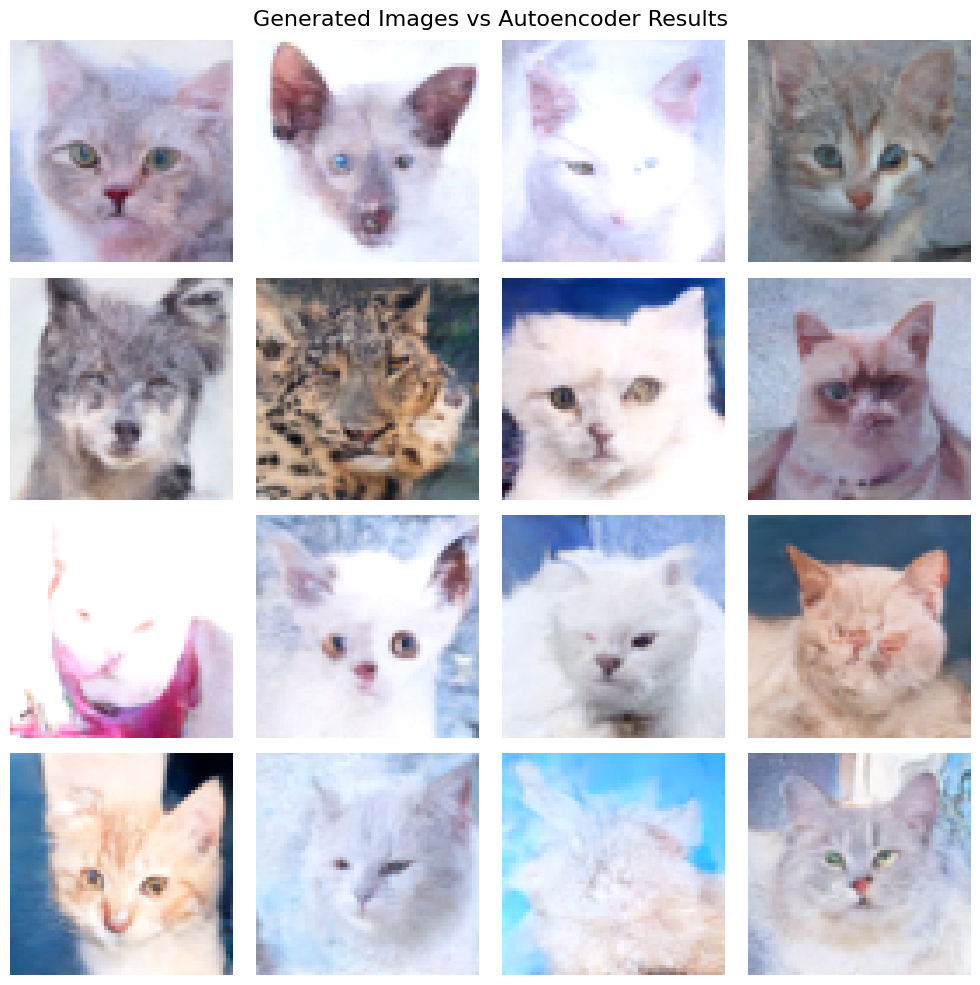

In [185]:
sampled_images = ddpm.sample(model, n=16, size=img_size)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    img = sampled_images[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
plt.suptitle("Generated Images vs Autoencoder Results", fontsize=16)
plt.tight_layout()
plt.show()

## Summary: DiffusionUNet vs. Autoencoders on AFHQ

We implemented a 2D Denoising Diffusion Probabilistic Model (DDPM) using a U-Net architecture (DiffusionUNet) from scratch and trained it on the Animal Faces HQ (AFHQ) dataset.


**Results & Comparison:**

When comparing these preliminary results to typical Autoencoder outputs on the same dataset:
* **Autoencoders (AE/VAE):** Usually produce smooth, sometimes blurry, but structurally coherent images quite early in training. They learn a compressed latent representation and reconstruct the image in a single pass.
* **Diffusion Models:** Require a significantly longer training process. The generation is a gradual, iterative denoising process. The current noisy results indicate that the model has not yet fully converged. While autoencoders might quickly yield a recognizable (though perhaps unsharp) animal face, diffusion models need hundreds of epochs to transition from generating pure noise to producing the highly detailed, photorealistic images they are known for.

**Conclusion:**
To achieve results that surpass those of standard autoencoders, the DiffusionUNet would require substantially more training epochs (e.g., 200+), potentially a larger network capacity, and careful tuning of the diffusion hyperparameters. The current state demonstrates the correct implementation of the forward and reverse diffusion processes, but highlights the extensive computational requirements necessary for these generative models to fully converge.